# Experiment 1 — Does TSLA news sentiment correlate with TSLA stock movement (2024–2026)?

**Hypothesis:** TSLA news sentiment is correlated with TSLA's daily stock movement over 2024–2026,
tested both **contemporaneously** (sentiment on day *t* vs. return on day *t*) and
**predictively** (sentiment on day *t* vs. return on day *t+1*).

**Method (kept deliberately simple):**
1. Parse ~4,770 CNBC article files under `../data/tsla/`.
2. Clean the article bodies (strip image links, video captions, promos).
3. Score sentiment with **VADER** (headline + body).
4. Aggregate to a daily mean sentiment.
5. Pull daily TSLA OHLCV bars from Alpaca (reusing `../get_bars.py`) and compute daily returns.
6. Align news to the next trading day, merge, and correlate (Pearson + Spearman, lag 0 and lag +1).
7. Plot and state a verdict.

*Limitations to keep in mind:* correlation ≠ causation (same-day news partly **reacts** to price);
VADER is general-purpose, not finance-tuned; the corpus is CNBC-only and 2026 is partial (through ~April).

In [1]:
# 1. Setup
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from dotenv import load_dotenv
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# The notebook lives in experiment_1/ ; the repo root is its parent.
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "experiment_1" else Path.cwd()
DATA_DIR = REPO_ROOT / "data" / "tsla"
load_dotenv(REPO_ROOT / ".env")

analyzer = SentimentIntensityAnalyzer()
print("Repo root :", REPO_ROOT)
print("Data dir  :", DATA_DIR, "| exists:", DATA_DIR.exists())

Repo root : /Users/georgia/Documents/Trading/sentimental_trading
Data dir  : /Users/georgia/Documents/Trading/sentimental_trading/data/tsla | exists: True


## 2. Load & parse the news corpus
Each article is a Markdown file with 5-field YAML frontmatter (`ticker`, `date`, `url`, `title`, `scraped_at`) followed by the body. We split on the `---` fences — no YAML library needed.

In [2]:
# 2. Parse every article into [date, title, body]
def parse_article(path):
    text = path.read_text(encoding="utf-8", errors="ignore")
    if not text.startswith("---"):
        return None
    parts = text.split("---", 2)           # ['', frontmatter, body]
    if len(parts) < 3:
        return None
    fm, body = parts[1], parts[2]
    meta = {}
    for line in fm.strip().splitlines():
        if ":" in line:
            key, _, val = line.partition(":")
            meta[key.strip()] = val.strip().strip('"')
    if not meta.get("date"):
        return None
    return {"date": meta["date"], "title": meta.get("title", ""), "body": body}

rows = []
for year in ["2024", "2025", "2026"]:
    for p in sorted((DATA_DIR / year).glob("*.md")):
        rec = parse_article(p)
        if rec:
            rows.append(rec)

news = pd.DataFrame(rows)
news["date"] = pd.to_datetime(news["date"]).dt.normalize()
print(f"{len(news):,} articles parsed")
print("Date range:", news["date"].min().date(), "->", news["date"].max().date())
news[["date", "title"]].head()

4,770 articles parsed
Date range: 2024-01-01 -> 2026-04-08


,date,title
0,2024-01-01,BYD beats Tesla for a second straight year aft...
1,2024-01-02,5 things to know before the stock market opens...
2,2024-01-02,"Apple, most valuable company in world and key ..."
3,2024-01-02,CNBC Daily Open: 2023’s winners and losers
4,2024-01-02,CNBC Daily Open: A disappointing start to the ...


## 3. Clean the article bodies
Remove image links, keep the visible text of hyperlinks, and drop CNBC boilerplate lines (`watch now`, `VIDEO...`, stock-chart captions, the trailing promo).

In [3]:
# 3. Body cleaning
PROMO_PAT = re.compile(r"Choose CNBC as your preferred source", re.I)
VIDEO_PAT = re.compile(r"^VIDEO\d")

def clean_body(body):
    text = re.sub(r"!\[[^\]]*\]\([^)]*\)", " ", body)      # drop images
    text = re.sub(r"\[([^\]]*)\]\([^)]*\)", r"\1", text)     # links -> visible text
    keep = []
    for line in text.splitlines():
        s = line.strip()
        if not s:
            continue
        low = s.lower()
        if low == "watch now" or low == "in this article":
            continue
        if VIDEO_PAT.match(s) or s.startswith("Stock Chart Icon"):
            continue
        if PROMO_PAT.search(s):
            continue
        s = re.sub(r"^#+\s*", "", s)     # strip heading markers
        s = s.strip("_ ")                # strip italic/contributor markers
        if s:
            keep.append(s)
    return " ".join(keep)

news["clean_body"] = news["body"].apply(clean_body)
# sanity check on one article
print(news["clean_body"].iloc[0][:400], "...")

BYD beats Tesla for a second straight year after producing more than 3 million cars in 2023 -   ZE594-CN -   TSLA BYD launched the BYD Seal in Europe at the IAA auto show in Munich, Germany. The electric sedan has a starting price of 44,900 euros ($48,479). Arjun Kharpal | CNBC BEIJING — BYD produced more than 3 million new energy vehicles in 2023, surpassing Tesla's production for a second straig ...


## 4. Score sentiment with VADER
Headline gets a single compound score. The body is split into sentences and we average their compound scores (avoids VADER's long-document saturation). The article score is the mean of the two.

In [4]:
# 4. VADER scoring
SENT_SPLIT = re.compile(r"(?<=[.!?])\s+")

def sentence_sentiment(text):
    sents = [s for s in SENT_SPLIT.split(text) if s.strip()]
    if not sents:
        return 0.0
    return float(np.mean([analyzer.polarity_scores(s)["compound"] for s in sents]))

news["headline_score"] = news["title"].apply(lambda t: analyzer.polarity_scores(t)["compound"])
news["body_score"] = news["clean_body"].apply(sentence_sentiment)
news["article_score"] = news[["headline_score", "body_score"]].mean(axis=1)
news[["date", "title", "headline_score", "body_score", "article_score"]].head()

,date,title,headline_score,body_score,article_score
0,2024-01-01,BYD beats Tesla for a second straight year aft...,0.2263,0.051186,0.138743
1,2024-01-02,5 things to know before the stock market opens...,0.0000,-0.002447,-0.001224
2,2024-01-02,"Apple, most valuable company in world and key ...",0.8070,0.169683,0.488342
3,2024-01-02,CNBC Daily Open: 2023’s winners and losers,-0.0772,0.110100,0.016450
4,2024-01-02,CNBC Daily Open: A disappointing start to the ...,0.4118,0.054356,0.233078


## 5. Aggregate to a daily sentiment series

In [5]:
# 5. Daily mean sentiment + article count (news volume)
daily_sent = (
    news.groupby("date")
    .agg(mean_sentiment=("article_score", "mean"),
         article_count=("article_score", "size"))
    .reset_index()
)
print(f"{len(daily_sent):,} calendar days carry >=1 article")
daily_sent.describe()

752 calendar days carry >=1 article


,date,mean_sentiment,article_count
count,752,752.000000,752.000000
mean,2025-02-04 03:32:33.191489,0.092015,6.343085
min,2024-01-01 00:00:00,-0.529719,1.000000
25%,2024-07-15 18:00:00,0.026239,2.000000
50%,2025-01-30 12:00:00,0.089702,5.000000
75%,2025-08-19 06:00:00,0.163837,8.000000
max,2026-04-08 00:00:00,0.621300,39.000000
std,NaN,0.130634,5.827010


## 6. Fetch daily TSLA prices
We reuse the `get_bars()` generator from `../get_bars.py` (already paginated, reads `.env`). We try the paid **SIP** feed first and fall back to the free **IEX** feed on a 403.

In [6]:
# 6. Daily bars via the existing get_bars generator
sys.path.insert(0, str(REPO_ROOT))
import get_bars as gb

def fetch_daily_bars(feed):
    params = {
        "timeframe": "1Day",
        "start": "2024-01-01T00:00:00Z",
        "end": "2026-04-09T00:00:00Z",
        "limit": 1000,
        "adjustment": "split",
        "feed": feed,
        "sort": "asc",
    }
    return list(gb.get_bars(params))

try:
    bars = fetch_daily_bars("sip")
    feed_used = "sip"
except Exception as e:
    print("SIP feed failed:", repr(e))
    print("Falling back to IEX (free tier)...")
    bars = fetch_daily_bars("iex")
    feed_used = "iex"

prices = pd.DataFrame(bars)
prices["date"] = pd.to_datetime(prices["t"], utc=True).dt.tz_localize(None).dt.normalize()
prices = prices.sort_values("date").reset_index(drop=True)
prices["daily_return"] = prices["c"].pct_change()
print(f"{len(prices)} daily bars via feed={feed_used}")
prices[["date", "o", "c", "daily_return"]].head()

568 daily bars via feed=sip


,date,o,c,daily_return
0,2024-01-02,250.08,248.42,NaN
1,2024-01-03,244.98,238.45,-0.040134
2,2024-01-04,239.25,237.93,-0.002181
3,2024-01-05,236.86,237.49,-0.001849
4,2024-01-08,236.14,240.45,0.012464


## 7. Align news to trading days and merge
Markets are closed on weekends/holidays, so each article is assigned to the **first trading day on or after** its date (Friday-evening and weekend news lands on Monday). When several news-days map to one trading day, sentiment is combined as an article-count-weighted mean.

In [7]:
# 7. Map each news date -> next trading day, then merge with returns
trading_days = prices["date"].to_numpy()

def next_trading_day(d):
    idx = np.searchsorted(trading_days, np.datetime64(d), side="left")
    return pd.Timestamp(trading_days[idx]) if idx < len(trading_days) else pd.NaT

daily_sent["trading_day"] = daily_sent["date"].apply(next_trading_day)

tmp = daily_sent.dropna(subset=["trading_day"]).copy()
tmp["weighted"] = tmp["mean_sentiment"] * tmp["article_count"]
sent_by_td = (
    tmp.groupby("trading_day")
    .agg(weighted=("weighted", "sum"), article_count=("article_count", "sum"))
    .reset_index()
)
sent_by_td["mean_sentiment"] = sent_by_td["weighted"] / sent_by_td["article_count"]
sent_by_td = sent_by_td.rename(columns={"trading_day": "date"})[["date", "mean_sentiment", "article_count"]]

merged = prices.merge(sent_by_td, on="date", how="inner").sort_values("date").reset_index(drop=True)
merged["next_return"] = merged["daily_return"].shift(-1)   # return on the FOLLOWING trading day
print(f"{len(merged)} aligned trading days with both price and news")
merged[["date", "c", "daily_return", "next_return", "mean_sentiment", "article_count"]].head()

565 aligned trading days with both price and news


,date,c,daily_return,next_return,mean_sentiment,article_count
0,2024-01-02,248.42,NaN,-0.040134,0.164387,12
1,2024-01-03,238.45,-0.040134,-0.002181,0.161350,9
2,2024-01-04,237.93,-0.002181,-0.001849,-0.007069,6
3,2024-01-05,237.49,-0.001849,0.012464,0.084625,9
4,2024-01-08,240.45,0.012464,-0.022832,0.086440,9


## 8. Correlation tests
Pearson (linear) and Spearman (rank) correlations, at **lag 0** (same-day) and **lag +1** (predictive).

In [8]:
# 8. Correlations
def corr_report(x, y, label):
    m = x.notna() & y.notna()
    x2, y2 = x[m], y[m]
    pr, pp = stats.pearsonr(x2, y2)
    sr, sp = stats.spearmanr(x2, y2)
    return {"comparison": label, "n": int(m.sum()),
            "pearson_r": pr, "pearson_p": pp,
            "spearman_r": sr, "spearman_p": sp}

results = pd.DataFrame([
    corr_report(merged["mean_sentiment"], merged["daily_return"], "sentiment(t) vs return(t)  [same-day]"),
    corr_report(merged["mean_sentiment"], merged["next_return"], "sentiment(t) vs return(t+1)  [predictive]"),
])
results.round(4)

,comparison,n,pearson_r,pearson_p,spearman_r,spearman_p
0,sentiment(t) vs return(t) [same-day],564,0.1202,0.0042,0.1245,0.0031
1,sentiment(t) vs return(t+1) [predictive],564,-0.0244,0.5625,-0.0247,0.5588


## 9. Plots

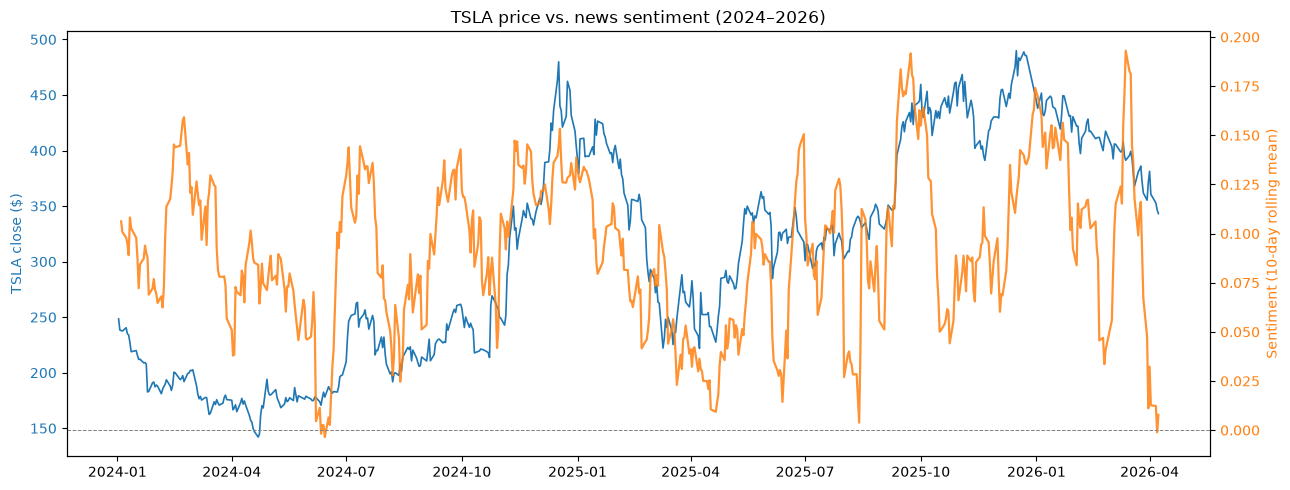

In [9]:
# 9a. Price vs. sentiment over time
fig, ax1 = plt.subplots(figsize=(13, 5))
ax1.plot(merged["date"], merged["c"], color="tab:blue", lw=1.2, label="TSLA close")
ax1.set_ylabel("TSLA close ($)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
roll = merged.set_index("date")["mean_sentiment"].rolling(10, min_periods=3).mean()
ax2.plot(roll.index, roll.values, color="tab:orange", lw=1.6, alpha=0.85, label="sentiment (10d mean)")
ax2.axhline(0, color="gray", ls="--", lw=0.7)
ax2.set_ylabel("Sentiment (10-day rolling mean)", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")
ax1.set_title("TSLA price vs. news sentiment (2024–2026)")
fig.tight_layout()
plt.show()

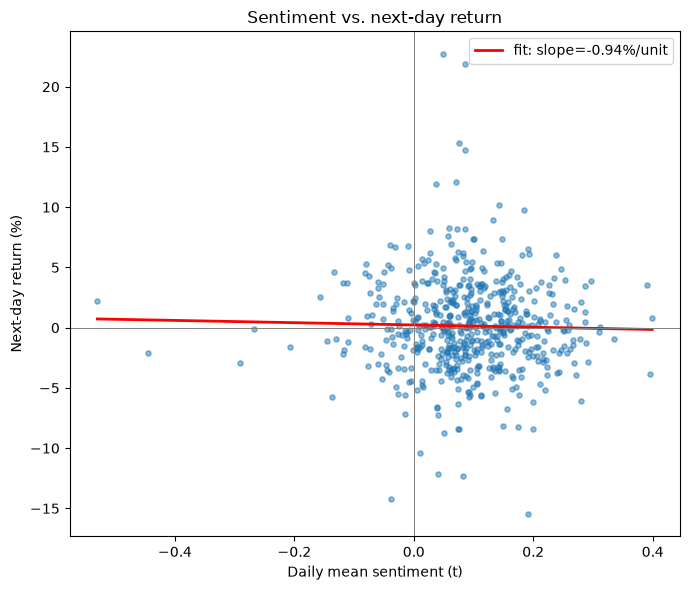

In [10]:
# 9b. Sentiment vs. next-day return
d = merged.dropna(subset=["mean_sentiment", "next_return"])
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(d["mean_sentiment"], d["next_return"] * 100, s=14, alpha=0.5)
m, b = np.polyfit(d["mean_sentiment"], d["next_return"] * 100, 1)
xs = np.linspace(d["mean_sentiment"].min(), d["mean_sentiment"].max(), 50)
ax.plot(xs, m * xs + b, color="red", lw=2, label=f"fit: slope={m:.2f}%/unit")
ax.axhline(0, color="gray", lw=0.7)
ax.axvline(0, color="gray", lw=0.7)
ax.set_xlabel("Daily mean sentiment (t)")
ax.set_ylabel("Next-day return (%)")
ax.set_title("Sentiment vs. next-day return")
ax.legend()
fig.tight_layout()
plt.show()

## 10. Verdict

In [11]:
# 10. Interpret & save
merged.to_csv("tsla_daily_merged.csv", index=False)

def interpret(r, p):
    a = abs(r)
    strength = ("negligible" if a < 0.1 else "weak" if a < 0.3 else
                "moderate" if a < 0.5 else "strong")
    direction = "positive" if r > 0 else "negative"
    sig = "significant" if p < 0.05 else "NOT significant"
    return f"{direction} {strength} (r={r:+.3f}, p={p:.4f}, {sig})"

print("HYPOTHESIS: TSLA news sentiment correlates with TSLA daily stock movement (2024–2026)")
print("=" * 78)
for _, row in results.iterrows():
    print(f"\n{row['comparison']}   (n={row['n']})")
    print("   Pearson :", interpret(row["pearson_r"], row["pearson_p"]))
    print("   Spearman:", interpret(row["spearman_r"], row["spearman_p"]))

print("\n" + "=" * 78)
print(f"Feed used: {feed_used} | aligned trading days: {len(merged)}")
print("Saved merged daily table -> tsla_daily_merged.csv")

best = results.loc[results["pearson_p"].idxmin()]
verdict = ("SUPPORTED" if best["pearson_p"] < 0.05 and abs(best["pearson_r"]) >= 0.1
           else "NOT SUPPORTED (no meaningful correlation)")
print(f"\nVERDICT: Hypothesis {verdict} — strongest signal is '{best['comparison'].strip()}'.")

HYPOTHESIS: TSLA news sentiment correlates with TSLA daily stock movement (2024–2026)

sentiment(t) vs return(t)  [same-day]   (n=564)
   Pearson : positive weak (r=+0.120, p=0.0042, significant)
   Spearman: positive weak (r=+0.125, p=0.0031, significant)

sentiment(t) vs return(t+1)  [predictive]   (n=564)
   Pearson : negative negligible (r=-0.024, p=0.5625, NOT significant)
   Spearman: negative negligible (r=-0.025, p=0.5588, NOT significant)

Feed used: sip | aligned trading days: 565
Saved merged daily table -> tsla_daily_merged.csv

VERDICT: Hypothesis SUPPORTED — strongest signal is 'sentiment(t) vs return(t)  [same-day]'.


### Reading the result

- A **significant same-day** correlation says sentiment and returns move together — but that is largely news *reacting* to the day's move, not a tradable edge.
- A **significant lag +1** correlation is the more interesting (predictive) claim: yesterday's sentiment relating to today's return.
- With VADER (general-purpose lexicon) on financial headlines, expect small coefficients; a weak-but-significant result over ~550 days is the realistic outcome. Treat this as a first-pass screen, not a trading signal.